# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [4]:
df_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [5]:
#Пропуски:
df_history.isna().sum()

user_id              0
session_id           0
session_date         0
session_start_ts     0
install_date         0
session_number       0
registration_flag    0
page_counter         0
region               0
device               0
dtype: int64

In [6]:
#Дубликаты:
df_history.duplicated().sum()

0

#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [7]:
df_history_gr = df_history.groupby('user_id')['session_id'].nunique().reset_index().sort_values(by = 'session_id', ascending = False).head(1)
display(df_history_gr)

,user_id,session_id
8948,10E0DEFC1ABDBBE0,10


In [8]:
df_max = df_history.merge(df_history_gr, on = 'user_id', how ='inner')
display(df_max)

,user_id,session_id_x,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,session_id_y
0,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android,10
1,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android,10
2,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android,10
3,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android,10
4,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android,10
5,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android,10
6,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android,10
7,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android,10
8,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android,10
9,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android,10


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [9]:
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [10]:
df_history['session_date'] = pd.to_datetime(df_history['session_date'])
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            435924 non-null  object        
 1   session_id         435924 non-null  object        
 2   session_date       435924 non-null  datetime64[ns]
 3   session_start_ts   435924 non-null  object        
 4   install_date       435924 non-null  object        
 5   session_number     435924 non-null  int64         
 6   registration_flag  435924 non-null  int64         
 7   page_counter       435924 non-null  int64         
 8   region             435924 non-null  object        
 9   device             435924 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 33.3+ MB


In [11]:
#Число всех уникальных пользователей по дням:
df_users_per_day = df_history.groupby('session_date')['user_id'].nunique().sort_values(ascending = False)
display(df_users_per_day)

session_date
2025-08-22    17563
2025-08-29    16873
2025-08-23    16082
2025-08-28    15388
2025-09-05    15324
2025-08-21    15051
2025-08-30    14891
2025-08-27    14766
2025-08-15    14065
2025-09-04    13683
2025-08-24    13683
2025-08-25    13635
2025-08-20    13514
2025-08-26    13289
2025-08-31    13266
2025-09-06    13078
2025-09-03    12777
2025-09-01    12685
2025-09-02    12672
2025-09-10    12526
2025-09-07    12367
2025-08-16    12205
2025-08-19    12118
2025-09-08    11826
2025-09-09    11780
2025-08-17    11200
2025-08-18    10839
2025-08-14    10321
2025-09-11     8623
2025-08-13     8489
2025-09-12     6436
2025-08-12     6056
2025-09-13     5183
2025-09-14     4364
2025-08-11     3919
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64

In [12]:
#Число уникальных пользователей :
users_uniq = df_history['user_id'].nunique()
display(users_uniq)

134039

In [13]:
#Число уникальных пользователей по дням:
users_uniq_per_day = df_history.groupby('session_date')['user_id'].nunique()
display(users_uniq_per_day)

session_date
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64

In [14]:
#Число уникальных зарегестрированных пользователей (registration_flag=1):
users_reg = df_history[df_history['registration_flag']==1]['user_id'].nunique()
display(users_reg)

13404

In [15]:
#Число уникальных зарегестрированных пользователей (registration_flag=1) по дням:
df_users_per_day_reg = df_history[df_history['registration_flag']==1].groupby('session_date')['user_id'].count().sort_values(ascending = False)
display(df_users_per_day_reg)

session_date
2025-08-23    1253
2025-08-22    1251
2025-08-24    1181
2025-08-28    1175
2025-08-29    1174
2025-08-30    1165
2025-08-31    1105
2025-08-27    1076
2025-09-07    1069
2025-08-21    1063
2025-08-25    1060
2025-08-26    1050
2025-09-02    1039
2025-09-03    1035
2025-09-05    1030
2025-09-01    1028
2025-09-06    1023
2025-09-10    1015
2025-09-08    1009
2025-08-20    1008
2025-09-04    1007
2025-09-09     980
2025-08-16     916
2025-08-18     860
2025-08-15     840
2025-08-17     833
2025-08-19     831
2025-09-11     824
2025-09-12     669
2025-08-14     625
2025-09-13     537
2025-08-13     464
2025-09-14     440
2025-09-15     383
2025-08-12     336
2025-09-16     286
2025-09-17     272
2025-09-18     201
2025-08-11     169
2025-09-19     132
2025-09-20     107
2025-09-21      87
2025-09-22      68
2025-09-23      32
Name: user_id, dtype: int64

In [16]:
#Доля зарегестрированных пользователей от всех пользователей за каждый день:
reg_users_share = (df_users_per_day_reg/users_uniq_per_day)
display(reg_users_share)

session_date
2025-08-11    0.043123
2025-08-12    0.055482
2025-08-13    0.054659
2025-08-14    0.060556
2025-08-15    0.059723
2025-08-16    0.075051
2025-08-17    0.074375
2025-08-18    0.079343
2025-08-19    0.068576
2025-08-20    0.074589
2025-08-21    0.070627
2025-08-22    0.071229
2025-08-23    0.077913
2025-08-24    0.086311
2025-08-25    0.077741
2025-08-26    0.079013
2025-08-27    0.072870
2025-08-28    0.076358
2025-08-29    0.069579
2025-08-30    0.078235
2025-08-31    0.083296
2025-09-01    0.081041
2025-09-02    0.081992
2025-09-03    0.081005
2025-09-04    0.073595
2025-09-05    0.067215
2025-09-06    0.078223
2025-09-07    0.086440
2025-09-08    0.085320
2025-09-09    0.083192
2025-09-10    0.081031
2025-09-11    0.095558
2025-09-12    0.103947
2025-09-13    0.103608
2025-09-14    0.100825
2025-09-15    0.103569
2025-09-16    0.094327
2025-09-17    0.106750
2025-09-18    0.102971
2025-09-19    0.093089
2025-09-20    0.097273
2025-09-21    0.112113
2025-09-22    0.12454

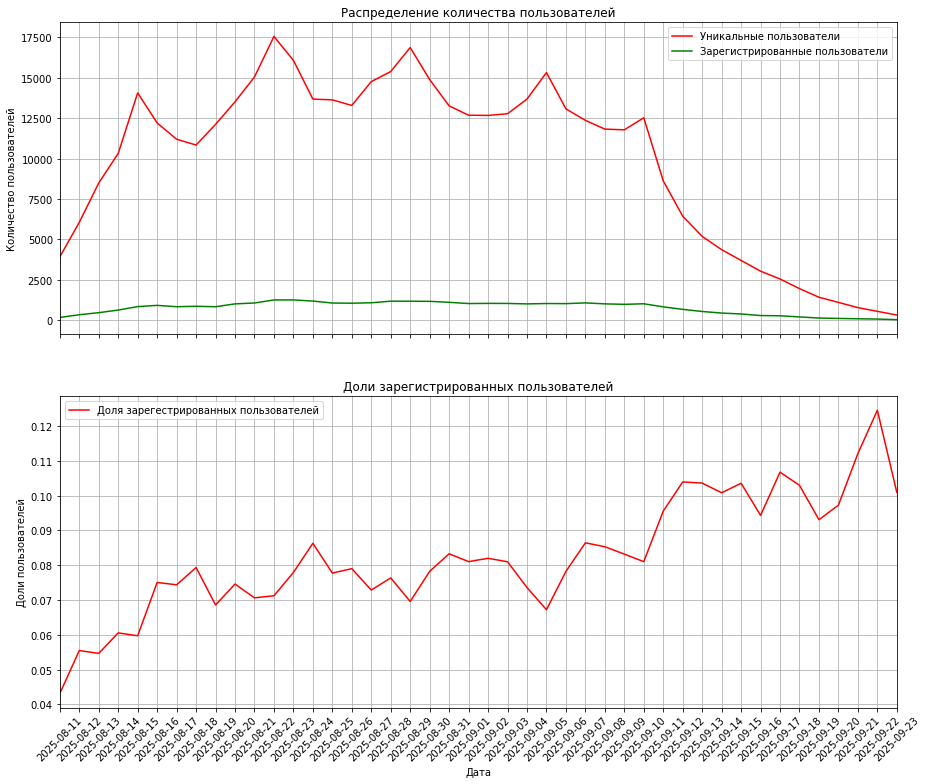

In [17]:
#Первый график - это линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.
#Второй график под ним - это линейный график доли зарегистрированных пользователей от всех пользователей по дням.

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(15, 14),sharex=True)

df_users_per_day.plot(kind='line', rot=45, color='red', legend=True, label='Уникальные пользователи', ax=ax1)
df_users_per_day_reg.plot(kind='line', rot=45, color='green', legend=True, label='Зарегистрированные пользователи', ax=ax1)

ax1.set_title('Распределение количества пользователей')
ax1.set_ylabel('Количество пользователей')
ax1.grid(True)


reg_users_share.plot(kind='line', rot=0, color='red', legend=True, label = 'Доля зарегестрированных пользователей', ax=ax2)

ax2.set_title('Доли зарегистрированных пользователей')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Доли пользователей')
ax2.grid(True)

import matplotlib.dates as mdates
all_dates = reg_users_share.index
ax2.set_xticks(all_dates)
ax2.tick_params(axis='x', rotation=45)

date_formatter = mdates.DateFormatter('%Y-%m-%d')
ax2.xaxis.set_major_formatter(date_formatter)


plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [18]:
#Количество сессий для каждого значения количества просмотренных страниц:
sessions_cnt_per_page = df_history.groupby('page_counter')['session_id'].count().reset_index()
display(sessions_cnt_per_page)

,page_counter,session_id
0,1,29160
1,2,105536
2,3,166690
3,4,105569
4,5,26288
5,6,2589
6,7,92


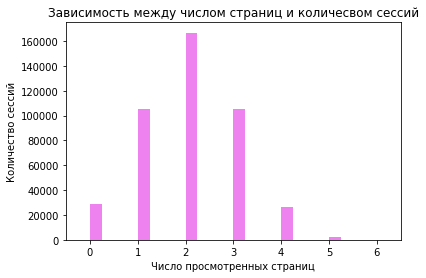

In [19]:
#Столбчатая диаграмма:
sessions_cnt_per_page.plot(kind = 'bar', rot = 0, color ='violet', legend = False)
plt.title('Зависимость между числом страниц и количесвом сессий')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')

plt.show()

Анализ числа просмотренных страниц:
- Распределение страниц выглядит нормальным.
- Наибольшее количество сессий: при 2 просмотренных страницах.
- Наименьшее количество сессий: при 6 просмотренных страницах.
Количество сессий увеличивается от 0 до 2 просмотренных страниц и после 2 до 6 - убывает.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

In [20]:
def count (v):
    if v >=4:
        return 1
    else:
        return 0
df_history['good_session'] = df_history['page_counter'].apply(count)
display(df_history)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0
...,...,...,...,...,...,...,...,...,...,...,...
435919,769BC199AF26FEF8,914903B51D69C5EA,2025-09-17,2025-09-17 21:33:57,2025-09-04,3,1,3,CIS,PC,0
435920,599DED39F3CD2ADE,66ADBE343C94DCDA,2025-09-17,2025-09-17 17:11:46,2025-09-04,4,0,4,MENA,iPhone,1
435921,1FA20C4BC94E64B2,C4CCD7E81733665F,2025-09-17,2025-09-17 19:36:55,2025-09-04,4,0,4,CIS,Android,1
435922,88E5FC3016A7A0AD,6834FB4914B56200,2025-09-17,2025-09-17 22:13:33,2025-09-04,5,0,4,MENA,PC,1


In [21]:
#Вычисляем количество успешных сессий по дням:
good_sesions_cnt = df_history['good_session'].sum()
good_sesions_per_day = df_history.groupby('session_date')['good_session'].count()
display(good_sesions_per_day)

session_date
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: good_session, dtype: int64

In [22]:
#Доля успешных сессий в каждый день: 
good_sesions_share = 100*(good_sesions_per_day/df_history.shape[0])
display(good_sesions_share)

session_date
2025-08-11    0.899010
2025-08-12    1.389233
2025-08-13    1.947358
2025-08-14    2.367615
2025-08-15    3.226480
2025-08-16    2.799800
2025-08-17    2.569255
2025-08-18    2.486443
2025-08-19    2.779842
2025-08-20    3.100082
2025-08-21    3.452666
2025-08-22    4.028913
2025-08-23    3.689175
2025-08-24    3.138850
2025-08-25    3.127839
2025-08-26    3.048467
2025-08-27    3.387288
2025-08-28    3.529973
2025-08-29    3.870629
2025-08-30    3.415962
2025-08-31    3.043191
2025-09-01    2.909911
2025-09-02    2.906929
2025-09-03    2.931015
2025-09-04    3.138850
2025-09-05    3.515292
2025-09-06    3.000064
2025-09-07    2.836962
2025-09-08    2.712858
2025-09-09    2.702306
2025-09-10    2.873437
2025-09-11    1.978097
2025-09-12    1.476404
2025-09-13    1.188969
2025-09-14    1.001092
2025-09-15    0.848313
2025-09-16    0.695534
2025-09-17    0.584506
2025-09-18    0.447784
2025-09-19    0.325286
2025-09-20    0.252338
2025-09-21    0.178013
2025-09-22    0.12525

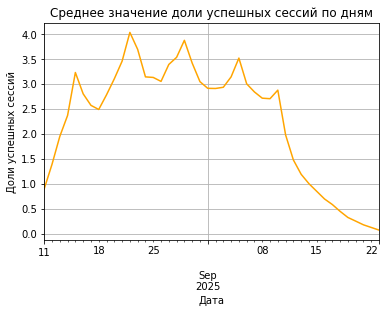

In [23]:
#График со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения:
good_sesions_share.plot(kind = 'line', rot = 0, color ='orange', legend = False)
plt.title('Среднее значение доли успешных сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доли успешных сессий')
plt.grid()

plt.show()

Анализ:

Полученный график показывает снижение доли успешных сессий в осеннее время. Также можно заметить, что по своей форме он напоминает график количества уникальных пользователей.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Как она будет учтена в формулировке гипотез?

Вероятно, речь идет о целевой метрике, которая будет отражать как реализуется нововведение. 

Целевой метрикой, в данном случае, будет служить доля успешных сессий.(Предроложительно оно увеличится)

Сформулируйте нулевую и альтернативную гипотезы:






**H₀:** доля успешных сессий в тестовой группе B меньше или равна, чем в контрольной группе A.

**H₁:** доля успешных сессий в тестовой группе B больше, чем в контрольной группе A.

#### 2.2. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [24]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03* p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [25]:
#Количество пользователей по дням:
cnt_users = df_history.groupby('session_date')['user_id'].count()
display(cnt_users)

session_date
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64

In [26]:
#Среднее от количества пользователей по дням:
cnt_users_mean = cnt_users.mean()
import math
cnt_users_mean = math.ceil(cnt_users_mean)
display(cnt_users_mean)

9908

In [27]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users =cnt_users_mean = cnt_users_mean

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9908 пользователей в день составит 9 дней


<!-- ✅⚠️⛔❌🚩 -->
<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">

##### ✅ Расчёт длительности A/B-теста
    
Тебя не смущает, что тест нужно проводить 27 лет? =)    

---

⛔️ Cначала нужно посчитать количество уникальных пользователей по дням, а затем взять среднее значение.    
    
---    
    
⛔️ В расчёте длительности теста не учтено sample_size и то, что A/B-тест состоит из двух групп (A и B).


Нужно умножить `sample_size` на 2 перед делением на `avg_daily_users`.    
    
---    

💬 Разумеется смущает :)
    
---
    
✅ xD    

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [28]:
df_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

In [29]:
df_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [30]:
df_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


In [31]:
df_test_part['session_date'] = pd.to_datetime(df_test_part['session_date'])
df_test_part['session_start_ts'] = pd.to_datetime(df_test_part['session_start_ts'])
df_test_part['install_date'] = pd.to_datetime(df_test_part['install_date'])
df_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            3130 non-null   object        
 1   session_id         3130 non-null   object        
 2   session_date       3130 non-null   datetime64[ns]
 3   session_start_ts   3130 non-null   datetime64[ns]
 4   install_date       3130 non-null   datetime64[ns]
 5   session_number     3130 non-null   int64         
 6   registration_flag  3130 non-null   int64         
 7   page_counter       3130 non-null   int64         
 8   region             3130 non-null   object        
 9   device             3130 non-null   object        
 10  test_group         3130 non-null   object        
dtypes: datetime64[ns](3), int64(3), object(5)
memory usage: 269.1+ KB


In [32]:
df_test_part.isna().sum()

user_id              0
session_id           0
session_date         0
session_start_ts     0
install_date         0
session_number       0
registration_flag    0
page_counter         0
region               0
device               0
test_group           0
dtype: int64

In [33]:
df_test_part.duplicated().sum() 

0

In [34]:
cnt_users = df_test_part.groupby('test_group')['user_id'].count()
display(cnt_users)

test_group
A    1502
B    1628
Name: user_id, dtype: int64

In [35]:
#Группа А:
cnt_users_A_per_day = df_test_part[df_test_part['test_group']=='A'].groupby('session_date')['user_id'].count().sort_values(ascending =False)
display(cnt_users_A_per_day)

session_date
2025-10-14    1502
Name: user_id, dtype: int64

In [36]:
#Группа B:
cnt_users_B_per_day = df_test_part[df_test_part['test_group']=='B'].groupby('session_date')['user_id'].count().sort_values(ascending =False)
display(cnt_users_B_per_day)

session_date
2025-10-14    1628
Name: user_id, dtype: int64

In [37]:
cnt_users_A = df_test_part[df_test_part['test_group']=='A']['user_id'].count()
display(cnt_users_A)

1502

In [38]:
cnt_users_B = df_test_part[df_test_part['test_group']=='B']['user_id'].count()
display(cnt_users_B)

1628

In [39]:
#Процентная разница в количестве пользователей в группах A и B:
P = (100*abs(cnt_users_A-cnt_users_B))/cnt_users_A
display(f'Процентная разница в количестве пользователей в группах A и B равна: {P}')

'Процентная разница в количестве пользователей в группах A и B равна: 8.388814913448735'

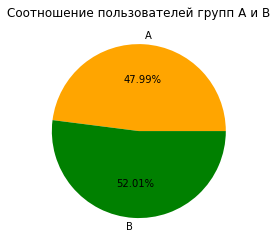

In [40]:
cnt_users.plot(
    kind= 'pie',
    title='Соотношение пользователей групп А и В',
    autopct= '%.2f%%',
    ylabel= '',
    colors= ['orange', 'green']
)

plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [41]:
group_A = df_test_part[df_test_part['test_group']=='A']['user_id']
group_B = df_test_part[df_test_part['test_group']=='B']['user_id']

[]


Множество получилось пустым - группы не пересекаются.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [43]:
group_A_device_cnt_gr = df_test_part[df_test_part['test_group']=='A'].groupby('device')['user_id'].count()
group_B_device_cnt_gr = df_test_part[df_test_part['test_group']=='B'].groupby('device')['user_id'].count()
display(group_A_device_cnt_gr, group_B_device_cnt_gr)

device
Android    656
Mac        160
PC         379
iPhone     307
Name: user_id, dtype: int64

device
Android    723
Mac        197
PC         402
iPhone     306
Name: user_id, dtype: int64

In [44]:
group_A_device_cnt = df_test_part[df_test_part['test_group']=='A']['device'].count()
group_B_device_cnt = df_test_part[df_test_part['test_group']=='B']['device'].count()
display(group_A_device_cnt, group_B_device_cnt)

1502

1628

In [45]:
group_A_device_share = group_A_device_cnt_gr/group_A_device_cnt
group_B_device_share = group_B_device_cnt_gr/group_B_device_cnt
display(group_A_device_share, group_B_device_share)

device
Android    0.436751
Mac        0.106525
PC         0.252330
iPhone     0.204394
Name: user_id, dtype: float64

device
Android    0.444103
Mac        0.121007
PC         0.246929
iPhone     0.187961
Name: user_id, dtype: float64

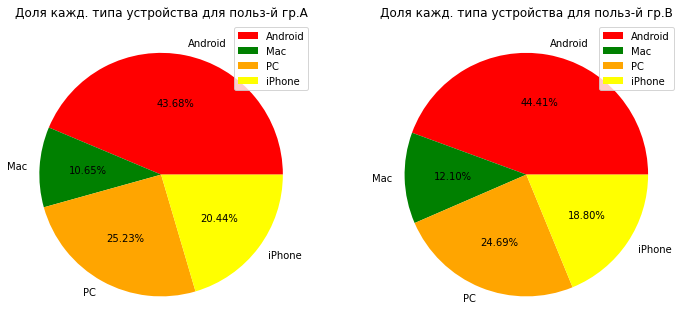

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
group_A_device_share.plot( ax=axes[0],
    kind= 'pie',
    legend = True,                      
    title='Доля кажд. типа устройства для польз-й гр.A',
    autopct= '%.2f%%',
    ylabel= '',
    colors= ['red', 'green', 'orange', 'yellow', 'blue']
)

group_B_device_share.plot( ax=axes[1],
    kind= 'pie',
    legend = True,                      
    title='Доля кажд. типа устройства для польз-й гр.В',
    autopct= '%.2f%%',
    ylabel= '',
    colors= ['red', 'green', 'orange', 'yellow', 'blue']
)
plt.show()

Градация популярности устройств среди всех пользователей, начиная от самого распространенного: Android, PC, iPhone, Mac. 


- Наиболее значимая разница по количеству пользователей в группах наблюдается в категориях: iPhone(1.64%), Mac (1.45%)
- Наблюдаются чуть большие колебания по сранению с другими категориями: Android (0.73%)
- В тестовой группе больше пользователей Android и Mac, меньше пользователей iPhone  и PC по сравнению с контрольной группой. 


#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


In [47]:
group_A_region_cnt_gr = df_test_part[df_test_part['test_group']=='A'].groupby('region')['user_id'].count()
group_B_region_cnt_gr = df_test_part[df_test_part['test_group']=='B'].groupby('region')['user_id'].count()
display(group_A_region_cnt_gr, group_B_region_cnt_gr)

region
CIS     656
EU      233
MENA    613
Name: user_id, dtype: int64

region
CIS     645
EU      220
MENA    763
Name: user_id, dtype: int64

In [48]:
group_A_region_cnt = df_test_part[df_test_part['test_group']=='A']['region'].count()
group_B_region_cnt = df_test_part[df_test_part['test_group']=='B']['region'].count()
display(group_A_region_cnt, group_B_region_cnt)

1502

1628

In [49]:
group_A_region_share = group_A_region_cnt_gr/group_A_region_cnt
group_B_region_share = group_B_region_cnt_gr/group_B_region_cnt
display(group_A_region_share, group_B_region_share)

region
CIS     0.436751
EU      0.155126
MENA    0.408123
Name: user_id, dtype: float64

region
CIS     0.396192
EU      0.135135
MENA    0.468673
Name: user_id, dtype: float64

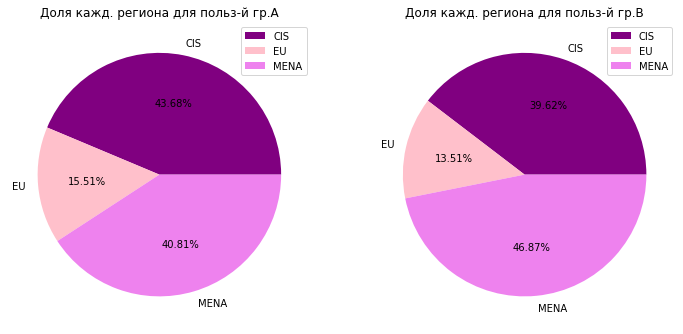

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
group_A_region_share.plot( ax=axes[0],
    kind= 'pie',
    legend = True,                      
    title='Доля кажд. региона для польз-й гр.А',
    autopct= '%.2f%%',
    ylabel= '',
    colors= ['purple', 'pink', 'violet']
)

group_B_region_share.plot( ax=axes[1],
    kind= 'pie',
    legend = True,                      
    title='Доля кажд. региона для польз-й гр.В',
    autopct= '%.2f%%',
    ylabel= '',
    colors= ['purple', 'pink', 'violet']
)
plt.show()

Наибольшая и заметная разница в категории региона: MENA (6.06%)

По остальным категориям: CIS (4.06%), EU (2%)

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

- Процентная разница в количестве пользователей в группах A и B равна: 1.82, можно сказать, что различие в количестве пользователей некретично.
- Выборки являются независимыми, поскольку пересечения между ними не обнаружено.
- По категориальным данным, в целом все равномерно распределено в обеих группах.
    - Но: Наблюдаются большие колебания по сранению с другими категориями: iPhone(1.64%), Mac (1.45%), меньшие колебания  Android (0.73%).
    - Наибольшая и весьма заметная разница в категории региона: MENA (6.06%), по остальным категориям: CIS (4.06%), EU (2%).

A/B-тест проходит корректо.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [51]:
df_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [52]:
df_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [53]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            100005 non-null  object
 1   session_id         100005 non-null  object
 2   session_date       100005 non-null  object
 3   session_start_ts   100005 non-null  object
 4   install_date       100005 non-null  object
 5   session_number     100005 non-null  int64 
 6   registration_flag  100005 non-null  int64 
 7   page_counter       100005 non-null  int64 
 8   region             100005 non-null  object
 9   device             100005 non-null  object
 10  test_group         100005 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


In [54]:
df_test['session_date'] = pd.to_datetime(df_test['session_date'])
df_test['session_start_ts'] = pd.to_datetime(df_test['session_start_ts'])
df_test['install_date'] = pd.to_datetime(df_test['install_date'])

df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            100005 non-null  object        
 1   session_id         100005 non-null  object        
 2   session_date       100005 non-null  datetime64[ns]
 3   session_start_ts   100005 non-null  datetime64[ns]
 4   install_date       100005 non-null  datetime64[ns]
 5   session_number     100005 non-null  int64         
 6   registration_flag  100005 non-null  int64         
 7   page_counter       100005 non-null  int64         
 8   region             100005 non-null  object        
 9   device             100005 non-null  object        
 10  test_group         100005 non-null  object        
dtypes: datetime64[ns](3), int64(3), object(5)
memory usage: 8.4+ MB


In [55]:
df_test.isna().sum()

user_id              0
session_id           0
session_date         0
session_start_ts     0
install_date         0
session_number       0
registration_flag    0
page_counter         0
region               0
device               0
test_group           0
dtype: int64

In [56]:
df_test.duplicated().sum()  

0

In [57]:
def good(g):
    if g>=4:
        return 1
    else: 
        return 0

df_test['good_session'] = df_test['page_counter'].apply(good)
display(df_test)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...
100000,CF77C27B238C1BE3,0F7BC9B33685377C,2025-10-22,2025-10-22 19:01:50,2025-10-20,3,0,3,MENA,Android,A,0
100001,D7ED66C581409AC2,26C4475005E70F47,2025-10-17,2025-10-17 22:12:38,2025-10-17,1,0,5,CIS,PC,A,1
100002,E7EA2D51238020C6,9B9CDE6A612CBD73,2025-10-24,2025-10-24 14:54:07,2025-10-14,2,0,3,MENA,PC,B,0
100003,8A6FEFD7F34C5DA1,37291EC27106EF9D,2025-10-18,2025-10-18 00:05:10,2025-10-14,3,0,4,EU,Android,B,1


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

In [58]:
cnt_session_A = df_test[df_test['test_group']=='A']['session_id'].count()
cnt_session_B = df_test[df_test['test_group']=='B']['session_id'].count()
display(cnt_session_A, cnt_session_B)

49551

50454

In [59]:
# Количество уникальных сессий для каждого дня и обеих тестовых групп:
cnt_session_A_gr = df_test[df_test['test_group']=='A'].groupby('session_date')['session_id'].count()
cnt_session_B_gr = df_test[df_test['test_group']=='B'].groupby('session_date')['session_id'].count()
display(cnt_session_A_gr, cnt_session_B_gr)

session_date
2025-10-14    1502
2025-10-15    2235
2025-10-16    3280
2025-10-17    4089
2025-10-18    5013
2025-10-19    6535
2025-10-20    5837
2025-10-21    3927
2025-10-22    3083
2025-10-23    2470
2025-10-24    2090
2025-10-25    1897
2025-10-26    1669
2025-10-27    1454
2025-10-28    1279
2025-10-29    1068
2025-10-30     887
2025-10-31     644
2025-11-01     434
2025-11-02     158
Name: session_id, dtype: int64

session_date
2025-10-14    1628
2025-10-15    2283
2025-10-16    3241
2025-10-17    4054
2025-10-18    5059
2025-10-19    6779
2025-10-20    6089
2025-10-21    3981
2025-10-22    3111
2025-10-23    2548
2025-10-24    2068
2025-10-25    1814
2025-10-26    1692
2025-10-27    1517
2025-10-28    1289
2025-10-29    1131
2025-10-30     876
2025-10-31     669
2025-11-01     465
2025-11-02     160
Name: session_id, dtype: int64

Формулируем гипотезы:
- H₀ (нулевая гипотеза) — количество уникальных дневных сессий не различается между тестовой и контрольной группами.
- H₁ (альтернативная гипотеза) — количество уникальных дневных сессий различается между тестовой и контрольной группами.


In [60]:
from scipy import stats as st
from scipy.stats import ttest_ind
alpha = 0.05
test_result = ttest_ind(
    cnt_session_A_gr,
    cnt_session_B_gr,
    alternative = 'two-sided'
)

display('p-значение:', test_result.pvalue)

if test_result.pvalue < alpha:
    display('Отвергаем нулевую гипотезу')
else:
    display('Не получилось отвергнуть нулевую гипотезу')


'p-значение:'

0.938219304859116

'Не получилось отвергнуть нулевую гипотезу'

Pvalue больше alpha, значит нулевая гипотеза подтверждается: количество уникальных дневных сессий не различается между тестовой и контрольной группами.

#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [61]:
lucky_A_sum = df_test[df_test['test_group']=='A']['good_session'].sum()
lucky_B_sum = df_test[df_test['test_group']=='B']['good_session'].sum()
display(lucky_A_sum, lucky_B_sum)

15248

16059

In [62]:
A_sum = df_test[df_test['test_group']=='A']['session_id'].count()
B_sum = df_test[df_test['test_group']=='B']['session_id'].count()
display(A_sum, B_sum)

49551

50454

In [63]:
#Расчет доли успешных сессий:
lucky_A_share= lucky_A_sum/A_sum
lucky_B_share= lucky_B_sum/B_sum
display(lucky_A_share, lucky_B_share)

0.3077233557344958

0.31828992745867524

In [64]:
#Процентная разница в группах A и B:
display(100*(lucky_B_share-lucky_A_share))

1.0566571724179463

Доля успешных сессий больше у группы В.

In [65]:
#Процентная разница в группах A и B по формуле:
P = (100*abs(A_sum-B_sum))/A_sum
display(f'Процентная разница в количестве пользователей в группах A и B равна: {P}')

'Процентная разница в количестве пользователей в группах A и B равна: 1.8223648362293394'

Разница между долями успешных сессий групп А и В составляет примерно 1.8%.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

Формируем гипотезы:
- H₀ (нулевая гипотеза): увеличение доли успешных сессий в группе В является случайным.
- H₁ (альтернативная гипотеза): увеличение доли успешных сессий в группе В является статистически значимым и не случайно.

In [66]:
#Используем Z-тест пропорций так как мы будем сравнивать доли в двух независимых выборках:
#Сначала проверим количество необходимых данных:
n_a = cnt_session_A
n_b = cnt_session_B
m_a = lucky_A_sum
m_b = lucky_B_sum

p_a, p_b = m_a/n_a, m_b/n_b

display(f'n_a={n_a}, n_b={n_b}')
display(f'm_a={m_a}, m_b={m_b}')
display(f'p_a={p_a}, p_b={p_b}')

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')



'n_a=49551, n_b=50454'

'm_a=15248, m_b=16059'

'p_a=0.3077233557344958, p_b=0.31828992745867524'

Предпосылка о достаточном количестве данных выполняется!


In [67]:
#Проводим сам тест:
from statsmodels.stats.proportion import proportions_ztest

n_a, n_b = 49551, 50454
m_a, m_b = 15248, 16059

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger'
)

p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.0001574739988036123 < 0.05
Нулевая гипотеза не находит подтверждения!


По результатам теста мы можем утверждать, что увеличение доли успешных сессий в группе В статистически значимо и не является случайным.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Было проведено А/В-тестирование для исследования влияния нового алгоритма рекомендаций:
- Была проведена выгрузка, работа с данными по сессиям пользователей из трех таблиц.
- Всего пользователей: 435 924.
- Всего зарегестрированных пользователей: 33708.
- Посчитано и исследовано число зарегестрированных пользователей в разные дни, число просмотренных страниц и их зависимость между количеством сессий.
- Можно отметить, что доля успешных сессий значительно снизилась в сентябре.
- Расчитаны:
  - размер выборки для проведения эксперимента: 41 040 для каждой группы,
  - длительности A/B-теста: 9 дней.
- В тестовой группе виден рост доли успешных сессий, что говорит нам о положительном влиянии нового алгоритма, к тому же этот рост статистически значим (pvalue=0.0003149479976072246)
- По результатам A/B-тестирования внедрять технологию стоит.

